# **1. Image Acquisition**

✅ Loaded image from local path: sunset.jpg


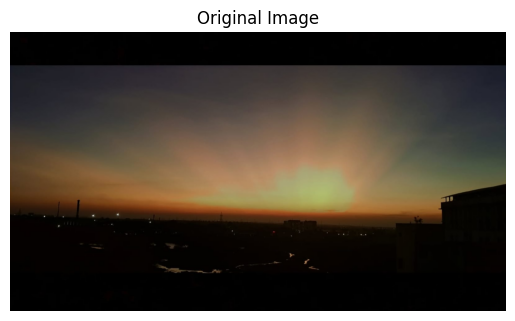

In [37]:
import os
import cv2
import matplotlib.pyplot as plt

def load_image(image_path='sunset.jpg'):
    """
    Load an image safely across Colab, Jupyter, and GitHub environments.
    If the image is not found locally, prompts upload (Colab only).
    """
    if os.path.exists(image_path):
        print(f"✅ Loaded image from local path: {image_path}")
        img = cv2.imread(image_path)
    else:
        try:
            from google.colab import files
            print("⚠️ Image not found locally. Please upload 'sunset.jpg' manually.")
            uploaded = files.upload()
            img = cv2.imread(list(uploaded.keys())[0])
        except ImportError:
            raise FileNotFoundError(f"Image file '{image_path}' not found. "
                                    "Please add it to your working directory.")
    if img is None:
        raise ValueError("Image loading failed! Check the file format or path.")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ---- Load and display image ----
img = load_image('sunset.jpg')
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()


# **2. Noise Simulation**

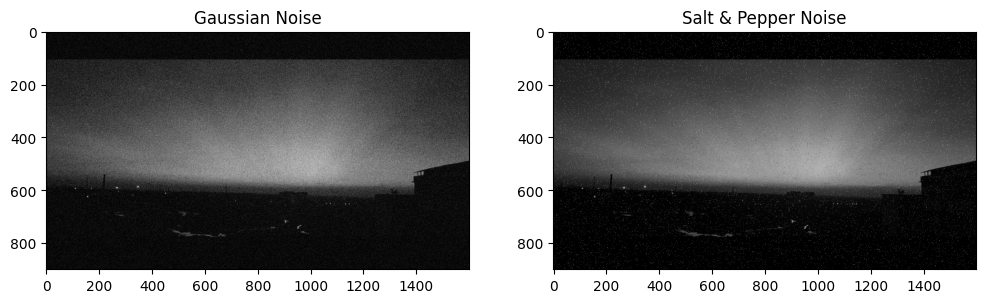

In [38]:
import numpy as np

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Gaussian Noise
gaussian_noise = gray + np.random.normal(0, 25, gray.shape)
gaussian_noise = np.clip(gaussian_noise, 0, 255).astype(np.uint8)

# Salt-and-Pepper Noise
s_p_noise = gray.copy()
prob = 0.02
rand = np.random.rand(*gray.shape)
s_p_noise[rand < prob/2] = 0
s_p_noise[rand > 1 - prob/2] = 255

# Show results
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.imshow(gaussian_noise, cmap="gray"); plt.title("Gaussian Noise")
plt.subplot(1,2,2); plt.imshow(s_p_noise, cmap="gray"); plt.title("Salt & Pepper Noise")
plt.show()


# **3. Preprocessing & Enhancement**

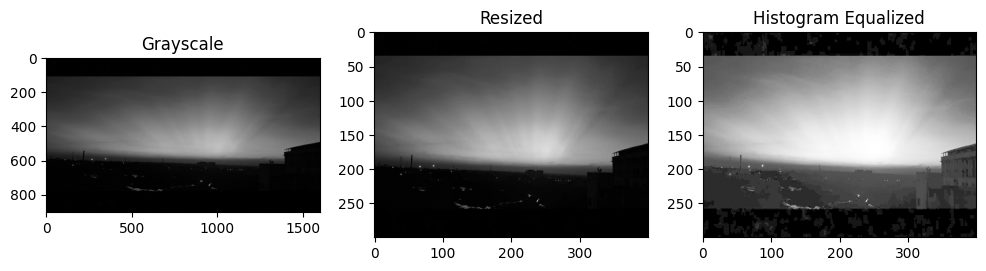

In [39]:
# Resize
resized = cv2.resize(gray, (400, 300))

# Histogram Equalization
hist_eq = cv2.equalizeHist(resized)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(gray, cmap="gray"); plt.title("Grayscale")
plt.subplot(1,3,2); plt.imshow(resized, cmap="gray"); plt.title("Resized")
plt.subplot(1,3,3); plt.imshow(hist_eq, cmap="gray"); plt.title("Histogram Equalized")
plt.show()


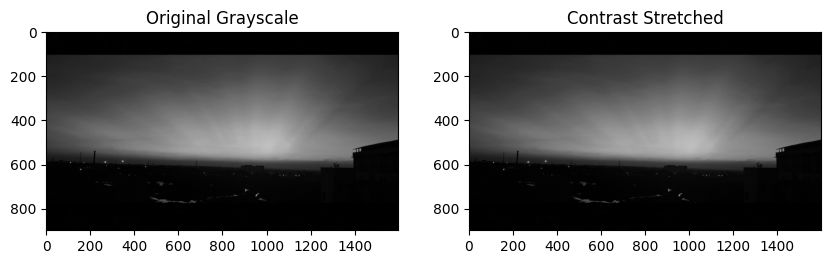

In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image (use your already converted gray image)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Contrast Stretching
min_val = np.min(gray)
max_val = np.max(gray)

contrast_stretched = ((gray - min_val) / (max_val - min_val)) * 255
contrast_stretched = contrast_stretched.astype(np.uint8)

# Show results
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(gray, cmap="gray"); plt.title("Original Grayscale")
plt.subplot(1,2,2); plt.imshow(contrast_stretched, cmap="gray"); plt.title("Contrast Stretched")
plt.show()


# **4. Filtering**

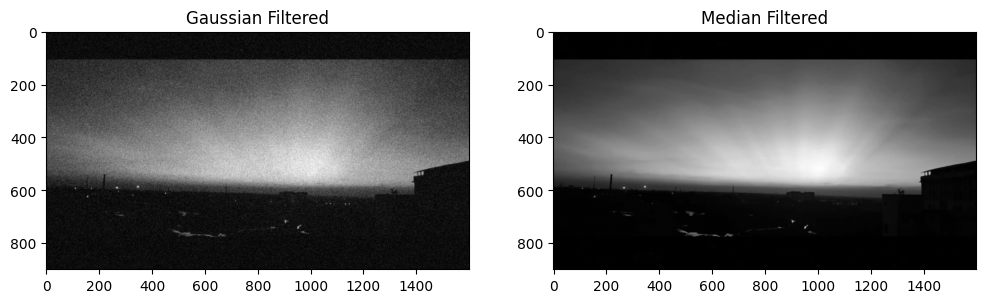

In [41]:
# Gaussian Filter
gaussian_filtered = cv2.GaussianBlur(gaussian_noise, (5,5), 0)

# Median Filter
median_filtered = cv2.medianBlur(s_p_noise, 5)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.imshow(gaussian_filtered, cmap="gray"); plt.title("Gaussian Filtered")
plt.subplot(1,2,2); plt.imshow(median_filtered, cmap="gray"); plt.title("Median Filtered")
plt.show()


In [42]:
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

# Compare noisy vs filtered
psnr_g = psnr(gray, gaussian_filtered)
ssim_g = ssim(gray, gaussian_filtered)

psnr_m = psnr(gray, median_filtered)
ssim_m = ssim(gray, median_filtered)

print("Gaussian Filter → PSNR:", psnr_g, " SSIM:", ssim_g)
print("Median Filter   → PSNR:", psnr_m, " SSIM:", ssim_m)


Gaussian Filter → PSNR: 29.665192195561048  SSIM: 0.47362147546113703
Median Filter   → PSNR: 44.913425776739274  SSIM: 0.9953818744962952


# **5. Segmentation and Object Isolation**

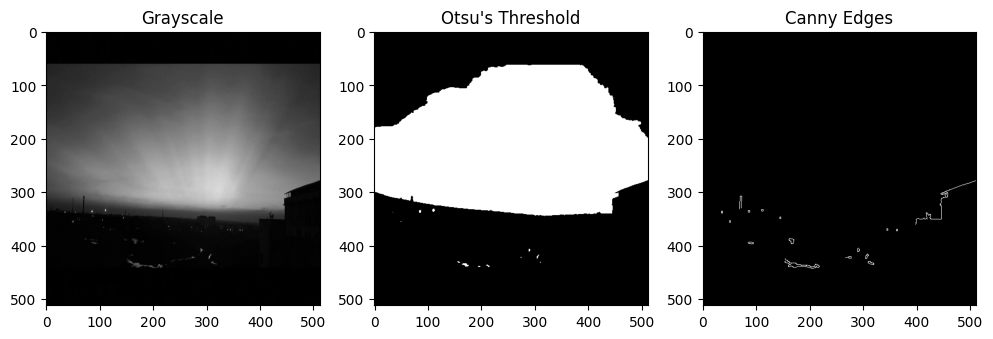

Segmentation complete using Otsu’s thresholding and edge detection.


In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the denoised or preprocessed image (from Assignment 1)
img = cv2.imread('sunset.jpg')
img = cv2.resize(img, (512, 512))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur for smoothing before segmentation
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Otsu's Thresholding
_, otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Edge-based Segmentation using Canny
edges = cv2.Canny(blur, 50, 150)

# Display results
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(gray, cmap='gray'); plt.title('Grayscale')
plt.subplot(1,3,2); plt.imshow(otsu, cmap='gray'); plt.title("Otsu's Threshold")
plt.subplot(1,3,3); plt.imshow(edges, cmap='gray'); plt.title('Canny Edges')
plt.show()

print("Segmentation complete using Otsu’s thresholding and edge detection.")


# **6. Feature Extraction**

Area: 111246.00, Centroid: (262,213)


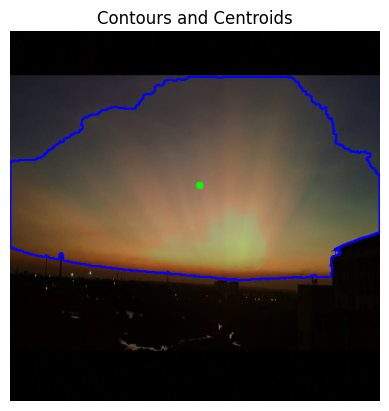

In [44]:
# Find contours on thresholded image
contours, hierarchy = cv2.findContours(otsu, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours and compute features
img_contours = img.copy()
for c in contours:
    area = cv2.contourArea(c)
    if area > 100:  # Ignore very small regions
        M = cv2.moments(c)
        if M["m00"] != 0:
            cx = int(M["m10"]/M["m00"])
            cy = int(M["m01"]/M["m00"])
            cv2.circle(img_contours, (cx, cy), 5, (0,255,0), -1)
        cv2.drawContours(img_contours, [c], -1, (255,0,0), 2)
        print(f"Area: {area:.2f}, Centroid: ({cx},{cy})")

plt.imshow(cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB))
plt.title('Contours and Centroids')
plt.axis('off')
plt.show()


# **7. Result Visualization and Reflection**

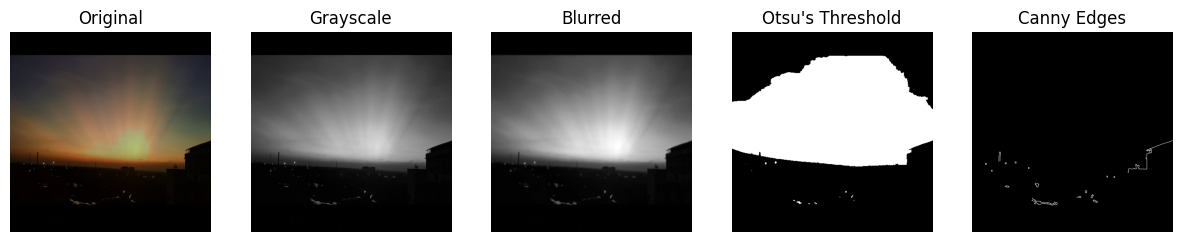


Reflection:
- Otsu’s thresholding effectively segmented bright and dark regions of the sunset.
- Canny edge detection highlighted horizon and structure boundaries.
- Median and Gaussian filters from Assignment 1 improved segmentation clarity.
- In future, region-based or k-means segmentation could separate clouds and sky regions better.



In [45]:
# Show full processing pipeline
titles = ['Original', 'Grayscale', 'Blurred', "Otsu's Threshold", 'Canny Edges']
images = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB), gray, blur, otsu, edges]

plt.figure(figsize=(15,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    cmap = 'gray' if len(images[i].shape)==2 else None
    plt.imshow(images[i], cmap=cmap)
    plt.title(titles[i])
    plt.axis('off')
plt.show()

print("""
Reflection:
- Otsu’s thresholding effectively segmented bright and dark regions of the sunset.
- Canny edge detection highlighted horizon and structure boundaries.
- Median and Gaussian filters from Assignment 1 improved segmentation clarity.
- In future, region-based or k-means segmentation could separate clouds and sky regions better.
""")
